In [306]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
sns.set(style='whitegrid')
from dotenv import load_dotenv
import os
from pathlib import Path
import pickle


import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

load_dotenv(override=True)

True

# Importing Data

In [266]:
project_root = Path.cwd().parent
data_path = project_root / os.getenv("DATA_PATH")
df = pd.read_csv(data_path)
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [215]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 34.9 MB


In [ ]:
# number_of_class1 = df[df['Response'] == 1].shape[0]

In [ ]:
# number_of_class0 = df[df['Response'] == 0].shape[0]

In [267]:
channel_mean = df.groupby("Policy_Sales_Channel")["Response"].mean()
df["channel_target"] = df["Policy_Sales_Channel"].map(channel_mean)

In [268]:
region_mean = df.groupby("Region_Code")["Response"].mean()
df["region_target"] = df["Region_Code"].map(region_mean)

In [269]:
vehicle_age_map = {
    "< 1 Year": 0,
    "1-2 Year": 1,
    "> 2 Years": 2
}

df["Vehicle_Age_num"] = df["Vehicle_Age"].map(vehicle_age_map)

df["Age_x_Vehicle_Age"] = df["Age"] * df["Vehicle_Age_num"]

channel_freq = df["Policy_Sales_Channel"].value_counts()
df["Channel_freq"] = df["Policy_Sales_Channel"].map(channel_freq)

df["Age_x_Channel"] = df["Age"] * df["Channel_freq"]

df["Vehicle_Damage_bin"] = (df["Vehicle_Damage"] == "Yes").astype(int)

df["Damage_x_NotInsured"] = (
    (df["Vehicle_Damage"] == "Yes") &
    (df["Previously_Insured"] == 0)
).astype(int)

In [ ]:
# freq = df["Policy_Sales_Channel"].value_counts()

# df["Policy_Sales_Channel_freq"] = df["Policy_Sales_Channel"].map(freq)

In [270]:
freq = df["Region_Code"].value_counts()

df["Region_Code_freq"] = df["Region_Code"].map(freq)

In [271]:
df["Age_x_Region"] = df["Age"] * df["Region_Code_freq"]

In [272]:
df["Damage_Age"] = (df["Vehicle_Damage"] == "Yes") & (df["Vehicle_Age"] == "> 2 Years")

In [ ]:
# df["damage_notinsured"] = (
#     (df["Vehicle_Damage"] == "Yes") &
#     (df["Previously_Insured"] == 0)
# ).astype(int)

In [234]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
 12  channel_target        381109 non-null  float64
 13  region_target         381109 non-null  float64
 14  Vehicle_Age_num       381109 non-null  int64  
 15  Age_x_Vehic

In [196]:
df.head(3)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,channel_target,region_target,Damage_Age,damage_notinsured
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1,0.199385,0.187163,True,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0,0.199385,0.127662,False,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1,0.199385,0.187163,True,1


In [277]:
df.drop(columns=['id','Policy_Sales_Channel','Region_Code','Vehicle_Age','Vehicle_Damage'], axis=0, inplace=True)

In [278]:
df = df.astype({
    "Gender" : "category",
    "Driving_License" : "category",
    # "Region_Code" : "category",
    "Previously_Insured" : "category",
    # "Vehicle_Damage" : "category",
    # "Annual_Premium" : "int",
    "Response" : "category"

})

In [280]:
cat_cols = df.select_dtypes(include=["object", "string", "category","bool"]).columns
num_cols = df.select_dtypes(exclude=["object", "string","category","bool"]).columns

In [275]:
df.iloc[:5,:]

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,...,region_target,Vehicle_Age_num,Age_x_Vehicle_Age,Channel_freq,Age_x_Channel,Vehicle_Damage_bin,Damage_x_NotInsured,Region_Code_freq,Age_x_Region,Damage_Age
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,...,0.187163,2,88,79700,3506800,1,1,106415,4682260,True
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,...,0.127662,1,76,79700,6057200,0,0,9251,703076,False
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,...,0.187163,2,94,79700,3745900,1,1,106415,5001505,True
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,...,0.112760,0,0,134784,2830464,0,0,9232,193872,False
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,...,0.121776,0,0,134784,3908736,0,0,18263,529627,False


In [279]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   Gender               381109 non-null  category
 1   Age                  381109 non-null  int64   
 2   Driving_License      381109 non-null  category
 3   Previously_Insured   381109 non-null  category
 4   Annual_Premium       381109 non-null  float64 
 5   Vintage              381109 non-null  int64   
 6   Response             381109 non-null  category
 7   channel_target       381109 non-null  float64 
 8   region_target        381109 non-null  float64 
 9   Vehicle_Age_num      381109 non-null  int64   
 10  Age_x_Vehicle_Age    381109 non-null  int64   
 11  Channel_freq         381109 non-null  int64   
 12  Age_x_Channel        381109 non-null  int64   
 13  Vehicle_Damage_bin   381109 non-null  int64   
 14  Damage_x_NotInsured  381109 non-null  int64   
 15  Region_Code

WAIT HERE

In [47]:
df = df[(df['Previously_Insured'] == 0) & (df['Vehicle_Damage'] == 'Yes')]

In [ ]:
df.drop(columns=['id','Previously_Insured','Vehicle_Damage','Policy_Sales_Channel','Vehicle_Age'], axis=0, inplace=True)

In [49]:
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns
num_cols = df.select_dtypes(exclude=["object", "string","category"]).columns

In [50]:
df.head()

,Gender,Age,Driving_License,Region_Code,Vehicle_Age,Annual_Premium,Vintage,Response,Policy_Sales_Channel_freq
0,Male,44,1,28.0,> 2 Years,40454,217,1,79700
2,Male,47,1,28.0,> 2 Years,38294,27,1,79700
5,Female,24,1,33.0,< 1 Year,2630,176,0,21779
6,Male,23,1,11.0,< 1 Year,23367,249,0,134784
7,Female,56,1,28.0,1-2 Year,32031,72,1,79700


In [14]:
df['Vehicle_Damage'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [86]:
df.drop(columns=['id','Previously_Insured','Vehicle_Damage'], axis=0, inplace=True)

In [ ]:
df = df.astype({
    "Gender" : "category",
    "Driving_License" : "category",
    "Region_Code" : "category",
    "Annual_Premium" : "int",
    "Response" : "category"

})

In [43]:
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns
num_cols = df.select_dtypes(exclude=["object", "string","category"]).columns

In [87]:
df.head()

,Gender,Age,Driving_License,Region_Code,Vehicle_Age,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,44,1,28.0,> 2 Years,40454.0,26.0,217,1
2,Male,47,1,28.0,> 2 Years,38294.0,26.0,27,1
5,Female,24,1,33.0,< 1 Year,2630.0,160.0,176,0
6,Male,23,1,11.0,< 1 Year,23367.0,152.0,249,0
7,Female,56,1,28.0,1-2 Year,32031.0,26.0,72,1


In [16]:
df1 = df[df['Response'] == 1].loc[:, ['Vehicle_Age','Driving_License','Previously_Insured','Vehicle_Damage','Vintage']]

In [17]:
df0 = df[df['Response'] == 0].loc[:, ['Vehicle_Age','Driving_License','Previously_Insured','Vehicle_Damage','Vintage']]

In [63]:
df1['Previously_Insured'].value_counts()

Previously_Insured
0    46552
1      158
Name: count, dtype: int64

In [64]:
df0['Previously_Insured'].value_counts()

Previously_Insured
1    174470
0    159929
Name: count, dtype: int64

* id: Unique ID for the customer
* Gender: Gender of the customer
* Age: Age of the customer
* Driving_License: [0 : Customer does not have DL, 1 : Customer already has DL]
* Region_Code: Unique code for the region of the customer
* Previously_Insured: [1 : Customer already has Vehicle Insurance, 0 : Customer doesn't have Vehicle Insurance]
* Vehicle_Age: Age of the Vehicle
* Vehicle_Damage: [1 : Customer got his/her vehicle damaged in the past. 0 : Customer didn't get his/her vehicle damaged in the past.]
* Annual_Premium: The amount customer needs to pay as premium in the year
* Policy_Sales_Channel: Anonymized Code for the channel of outreaching to the customer ie. Different Agents, Over Mail, Over Phone, In Person, etc.
* Vintage: Number of Days, Customer has been associated with the company
* Response: [1 : Customer is interested, 0 : Customer is not interested]

# EDA

In [10]:
df.shape

(381109, 12)

In [11]:
# checking for null values
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 34.9 MB


In [13]:
df.head(2)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0


In [23]:
for col in df.columns:
    print(f"{col} has below unique values:\n{df[col].unique()}\n\n")


Gender has below unique values:
['Male', 'Female']
Categories (2, str): ['Female', 'Male']


Age has below unique values:
[44 76 47 21 29 24 23 56 32 41 71 37 25 42 60 65 49 34 51 26 57 79 48 45
 72 30 54 27 38 22 78 20 39 62 58 59 63 50 67 77 28 69 52 31 33 43 36 53
 70 46 55 40 61 75 64 35 66 68 74 73 84 83 81 80 82 85]


Driving_License has below unique values:
[1, 0]
Categories (2, int64): [0, 1]


Region_Code has below unique values:
[28  3 11 41 33  6 35 50 15 45  8 36 30 26 16 47 48 19 39 23 37  5 17  2
  7 29 46 27 25 13 18 20 49 22 44  0  9 31 12 34 21 10 14 38 24 40 43 32
  4 51 42  1 52]


Previously_Insured has below unique values:
[0, 1]
Categories (2, int64): [0, 1]


Vehicle_Age has below unique values:
<StringArray>
['> 2 Years', '1-2 Year', '< 1 Year']
Length: 3, dtype: str


Vehicle_Damage has below unique values:
['Yes', 'No']
Categories (2, str): ['No', 'Yes']


Annual_Premium has below unique values:
[ 40454.  33536.  38294. ...  20706. 101664.  69845.]


Policy_Sa

In [ ]:
df = df.astype({
    "Gender" : "category",
    "Driving_License" : "category",
    "Region_Code" : "category",
    "Annual_Premium" : "int",
    "Response" : "category"

})

In [89]:
df.info()

<class 'pandas.DataFrame'>
Index: 182491 entries, 0 to 381107
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   Gender                182491 non-null  category
 1   Age                   182491 non-null  int64   
 2   Driving_License       182491 non-null  category
 3   Region_Code           182491 non-null  int64   
 4   Vehicle_Age           182491 non-null  str     
 5   Annual_Premium        182491 non-null  int64   
 6   Policy_Sales_Channel  182491 non-null  int64   
 7   Vintage               182491 non-null  int64   
 8   Response              182491 non-null  category
dtypes: category(3), int64(5), str(1)
memory usage: 10.3 MB


In [18]:
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns
num_cols = df.select_dtypes(exclude=["object", "string","category"]).columns

In [19]:
print(f"Numerical Columns:\n{num_cols}\n\n")
print(f"Categorical Columns:\n{cat_cols}")

Numerical Columns:
Index(['Age', 'Previously_Insured', 'Annual_Premium', 'Policy_Sales_Channel',
       'Vintage'],
      dtype='str')


Categorical Columns:
Index(['Gender', 'Driving_License', 'Region_Code', 'Vehicle_Age',
       'Vehicle_Damage', 'Response'],
      dtype='str')


In [27]:
df.describe()

,Age,Region_Code,Annual_Premium,Policy_Sales_Channel,Vintage
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,38.822584,26.388807,30564.389581,112.034295,154.347397
std,15.511611,13.229888,17213.155057,54.203995,83.671304
min,20.000000,0.000000,2630.000000,1.000000,10.000000
25%,25.000000,15.000000,24405.000000,29.000000,82.000000
50%,36.000000,28.000000,31669.000000,133.000000,154.000000
75%,49.000000,35.000000,39400.000000,152.000000,227.000000
max,85.000000,52.000000,540165.000000,163.000000,299.000000


In [30]:
df.describe(include=['object','str','category'])

,Gender,Driving_License,Previously_Insured,Vehicle_Age,Vehicle_Damage,Response
count,381109,381109,381109,381109,381109,381109
unique,2,2,2,3,2,2
top,Male,1,0,1-2 Year,Yes,0
freq,206089,380297,206481,200316,192413,334399


## Univariate Analysis

Distribution plot of Age


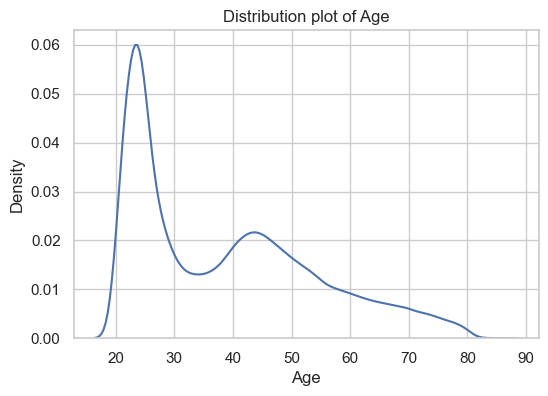

Distribution plot of Region_Code


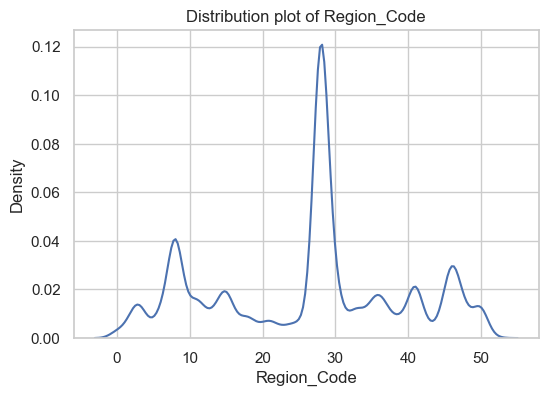

Distribution plot of Annual_Premium


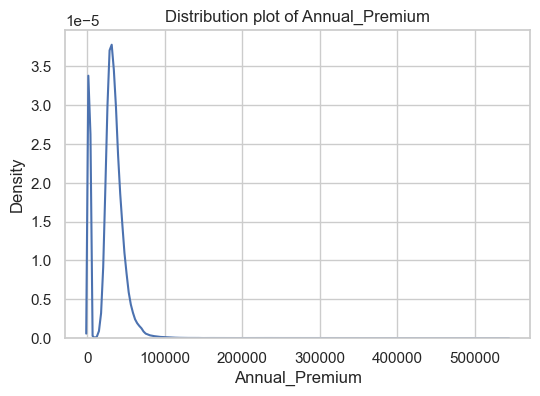

Distribution plot of Policy_Sales_Channel


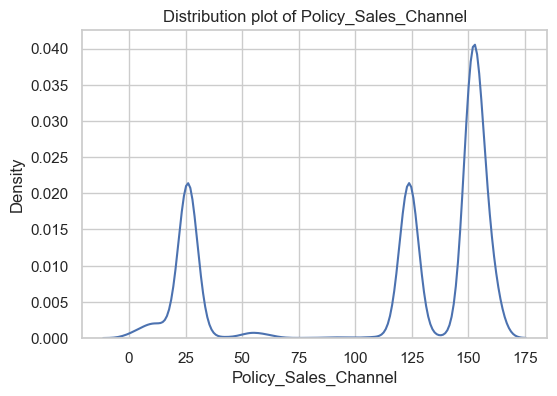

Distribution plot of Vintage


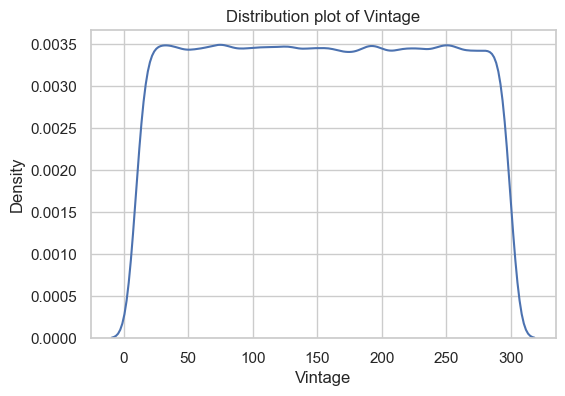

In [35]:
def dist_plot_num(df, num_cols):
    for col in num_cols:
        plt.figure(figsize=(6,4))
        print(f"Distribution plot of {col}")
        sns.kdeplot(df[col])
        plt.title(f"Distribution plot of {col}")
        plt.show()

dist_plot_num(df, num_cols)

Distribution plot of Gender


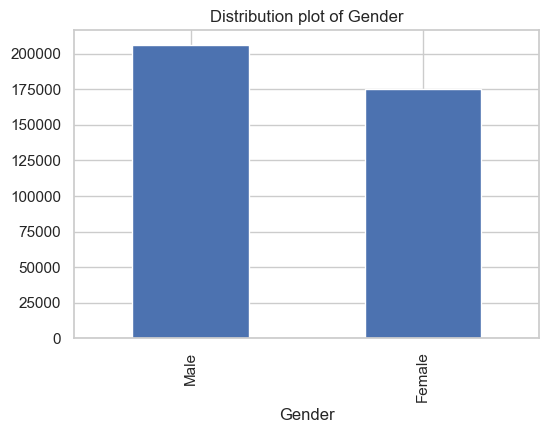

Distribution plot of Driving_License


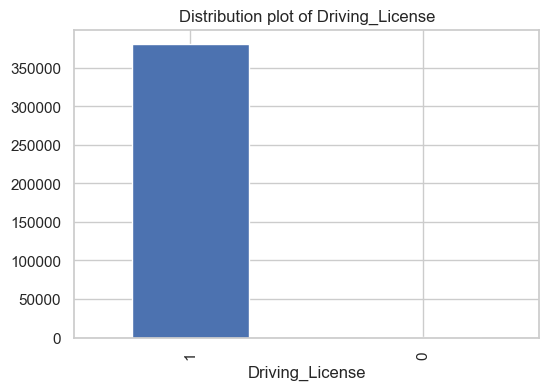

Distribution plot of Previously_Insured


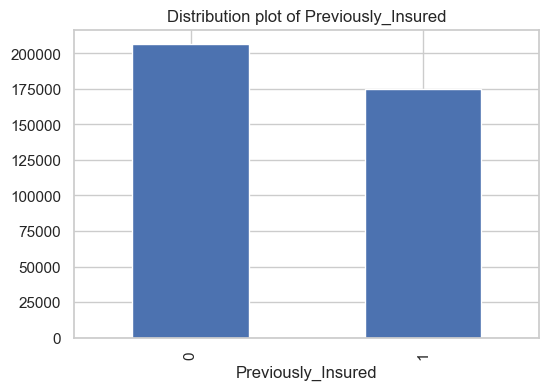

Distribution plot of Vehicle_Age


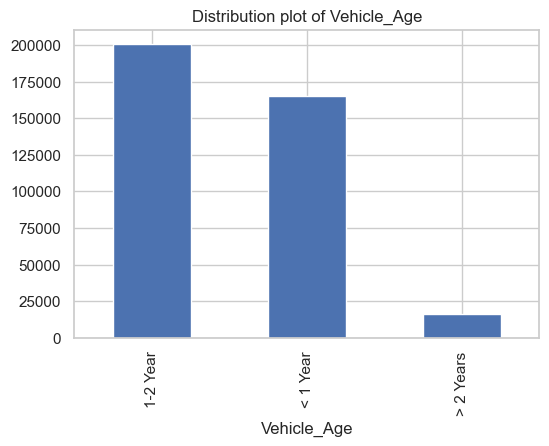

Distribution plot of Vehicle_Damage


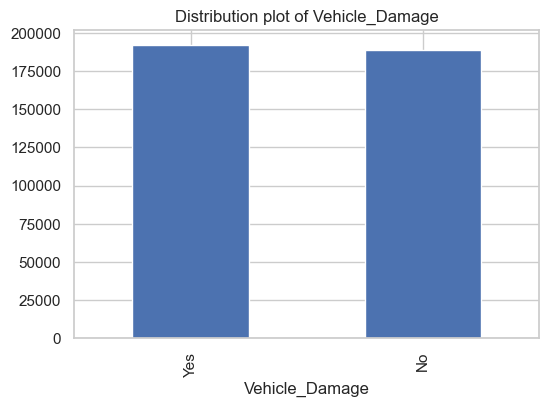

Distribution plot of Response


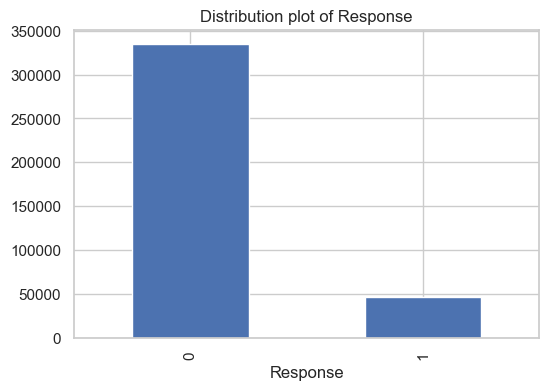

In [36]:
def dist_plot_cat(df, cat_cols):

    for col in cat_cols:
        if df[col].nunique() < 10:
            plt.figure(figsize=(6,4))
            print(f"Distribution plot of {col}")
            df[col].value_counts().plot(kind='bar')
            plt.title(f"Distribution plot of {col}")
            plt.show()

dist_plot_cat(df, cat_cols)

## Bivariate Analysis

Response vs Gender


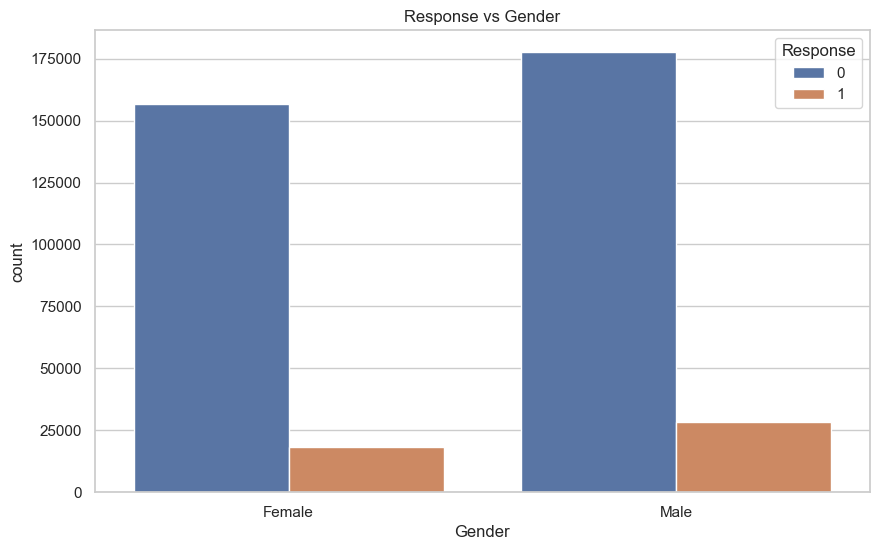

Response vs Driving_License


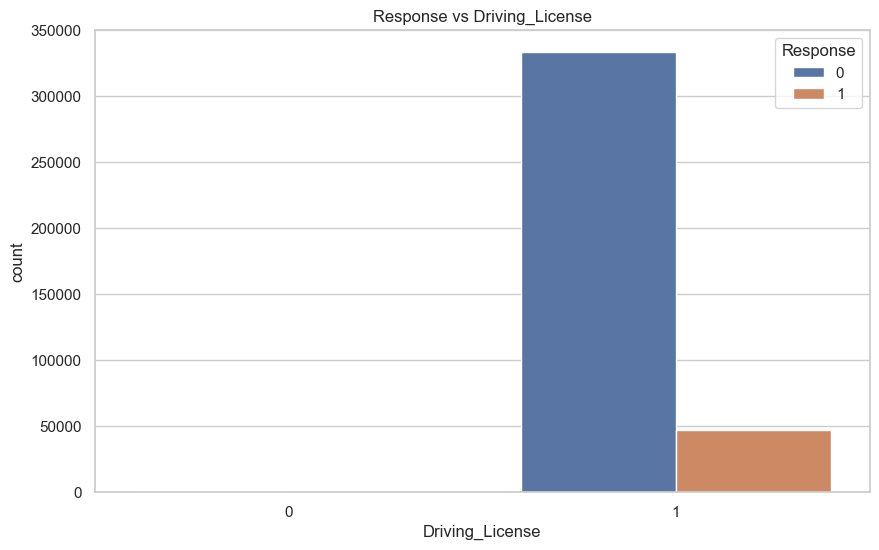

Response vs Previously_Insured


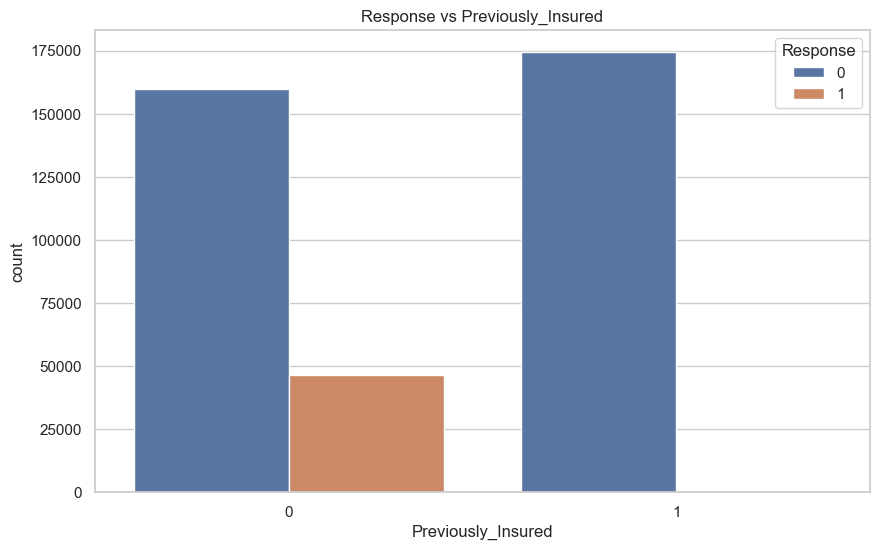

Response vs Vehicle_Age


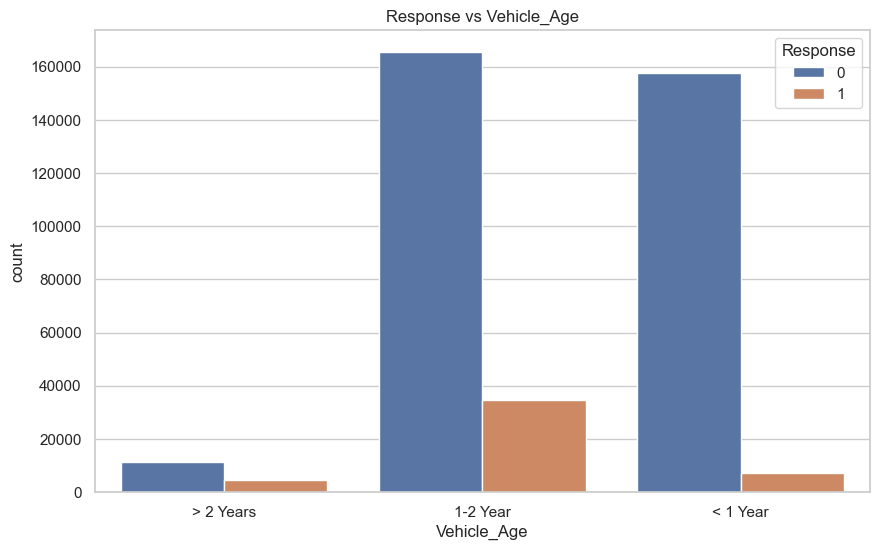

Response vs Vehicle_Damage


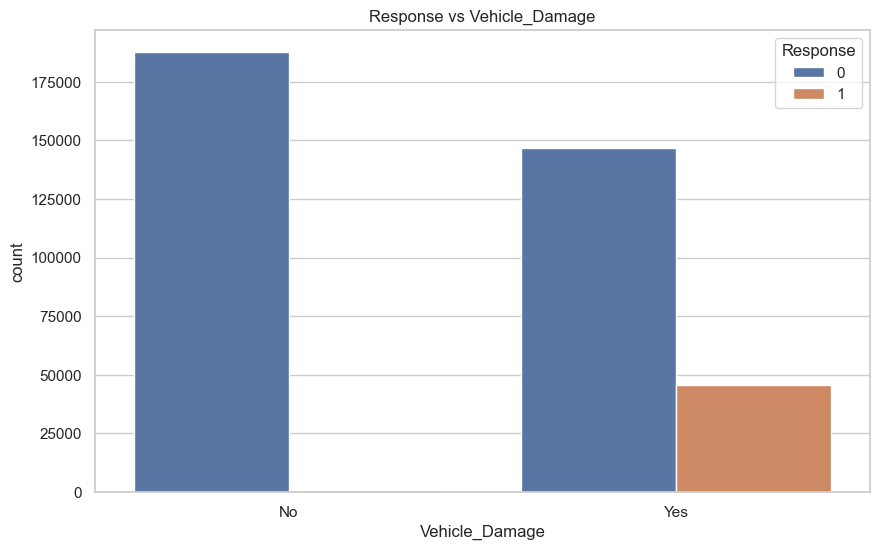

In [38]:
def target_analysis_plot(df, cat_cols, target_col):

    for col in cat_cols:
        if (df[col].nunique() < 10) and (col != target_col):
            plt.figure(figsize=(10,6))
            print(f"{target_col} vs {col}")
            sns.countplot(x=col, hue=target_col, data=df)
            plt.title(f"{target_col} vs {col}")
            plt.show()

target_analysis_plot(df, cat_cols, 'Response')

# Feature Engineering

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   Gender                381109 non-null  category
 1   Age                   381109 non-null  int64   
 2   Driving_License       381109 non-null  category
 3   Region_Code           381109 non-null  int64   
 4   Previously_Insured    381109 non-null  category
 5   Vehicle_Age           381109 non-null  str     
 6   Vehicle_Damage        381109 non-null  category
 7   Annual_Premium        381109 non-null  float64 
 8   Policy_Sales_Channel  381109 non-null  float64 
 9   Vintage               381109 non-null  int64   
 10  Response              381109 non-null  category
dtypes: category(5), float64(2), int64(3), str(1)
memory usage: 19.3 MB


In [281]:
print(f"Num Cols:\n{num_cols}\n")
print(f"Cat Cols:\n{cat_cols}")

Num Cols:
Index(['Age', 'Annual_Premium', 'Vintage', 'channel_target', 'region_target',
       'Vehicle_Age_num', 'Age_x_Vehicle_Age', 'Channel_freq', 'Age_x_Channel',
       'Vehicle_Damage_bin', 'Damage_x_NotInsured', 'Region_Code_freq',
       'Age_x_Region'],
      dtype='str')

Cat Cols:
Index(['Gender', 'Driving_License', 'Previously_Insured', 'Response',
       'Damage_Age'],
      dtype='str')


In [241]:
for col in cat_cols:
    print(f"{col} has below unique values:\n{df[col].unique()}\n")

Gender has below unique values:
['Male', 'Female']
Categories (2, str): ['Female', 'Male']

Driving_License has below unique values:
[1, 0]
Categories (2, int64): [0, 1]

Previously_Insured has below unique values:
[0, 1]
Categories (2, int64): [0, 1]

Vehicle_Damage has below unique values:
['Yes', 'No']
Categories (2, str): ['No', 'Yes']

Response has below unique values:
[1, 0]
Categories (2, int64): [0, 1]

Damage_Age has below unique values:
[ True False]



In [282]:
X = df.drop(columns=['Response'], axis=0)
y = df['Response']

In [283]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [286]:
X_train['Damage_Age']

274710    False
216539    False
78983     False
218368    False
307215    False
          ...  
378816    False
67726     False
91744     False
48700     False
221791    False
Name: Damage_Age, Length: 304887, dtype: bool

In [284]:
print(f"X_train shape:  {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape:  {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape:  (304887, 17)
X_test shape:  (76222, 17)
y_train shape:  (304887,)
y_test shape:  (76222,)


In [287]:
ohe_cols = cat_cols.drop(["Response"])
ohe_cols

Index(['Gender', 'Driving_License', 'Previously_Insured', 'Damage_Age'], dtype='str')

In [290]:
# ord_cols = cat_cols.drop(["Response",'Gender', 'Driving_License', 'Previously_Insured','Damage_Age'])
# ord_cols

In [291]:
# One-hot encode categorical columns
ohe = OneHotEncoder(drop='first', sparse_output=False)

X_train_ohe = ohe.fit_transform(X_train[ohe_cols])
X_test_ohe = ohe.transform(X_test[ohe_cols])


# # Ordinal encode Vehicle_Age
# oe = OrdinalEncoder(categories=[
#     ['< 1 Year', '1-2 Year', '> 2 Years']
# ])

# X_train_ord = oe.fit_transform(X_train[ord_cols])
# X_test_ord = oe.transform(X_test[ord_cols])


# Numeric features
X_train_num = X_train[num_cols].to_numpy()
X_test_num = X_test[num_cols].to_numpy()


# Combine everything
X_train_final = np.hstack((X_train_num, X_train_ohe))
X_test_final = np.hstack((X_test_num, X_test_ohe))

In [292]:
print(f"X_train shape:  {X_train_final.shape}")
print(f"X_test shape:  {X_test_final.shape}")

X_train shape:  (304887, 17)
X_test shape:  (76222, 17)


In [295]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

In [248]:
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver="liblinear",penalty="l1",class_weight="balanced")
rfc = RandomForestClassifier(n_estimators=200,class_weight="balanced",random_state=42)   
xgb  = XGBClassifier(n_estimators = 200, random_state = 2, scale_pos_weight = (number_of_class0 / number_of_class1))

In [179]:
clfs = {
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'xgb': xgb
    
}

In [180]:
def train_classifier(clf, X_train_scaled, y_train, X_test_scaled, y_test):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    mean_cv_score = cv_scores.mean()
    clf.fit(X_train_scaled,y_train)
    y_pred = clf.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return accuracy , precision, recall, f1, mean_cv_score

In [149]:
for name , clf in clfs.items():
    current_accuracy, current_precision, current_recall, current_f1, current_mean_cv_score = train_classifier(clf, X_train_scaled, y_train, X_test_scaled, y_test)
    print()
    print("For: ", name)
    print("Accuracy: ", current_accuracy)
    print("Precision: ", current_precision)
    print("Recall: ", current_recall)
    print("F1: ", current_f1)
    print("CV Score: ", current_mean_cv_score)


For:  DT
Accuracy:  0.8774369604576107
Precision:  0.0
Recall:  0.0
F1:  0.0
CV Score:  0.8774365584977636

For:  LR
Accuracy:  0.6401039070084752
Precision:  0.2510047899576061
Recall:  0.9760222650396061
F1:  0.39931680826837174
CV Score:  0.6389252345801542

For:  RF
Accuracy:  0.8689879562331085
Precision:  0.367816091954023
Recall:  0.09591093984157568
F1:  0.152148072677874
CV Score:  0.8693942321563526

For:  xgb
Accuracy:  0.7256697541392249
Precision:  0.2931774297361081
Recall:  0.8776493256262042
F1:  0.4395303956256031
CV Score:  0.7277876628524517


In [125]:
for name , clf in clfs.items():
    current_accuracy, current_precision, current_recall, current_f1, current_mean_cv_score = train_classifier(clf, X_train_scaled, y_train, X_test_scaled, y_test)
    print()
    print("For: ", name)
    print("Accuracy: ", current_accuracy)
    print("Precision: ", current_precision)
    print("Recall: ", current_recall)
    print("F1: ", current_f1)
    print("CV Score: ", current_mean_cv_score)


For:  DT
Accuracy:  0.8774369604576107
Precision:  0.5
Recall:  0.00010704345964461572
F1:  0.00021404109589041095
CV Score:  0.8774332786263344

For:  LR
Accuracy:  0.6519246411797119
Precision:  0.2560390587300236
Recall:  0.9655320059944338
F1:  0.4047474815462969
CV Score:  0.6505721720566451

For:  RF
Accuracy:  0.8679646296344887
Precision:  0.3708869814020029
Recall:  0.11100406765146649
F1:  0.17086834733893558
CV Score:  0.8677083593082159

For:  xgb
Accuracy:  0.7239510902364147
Precision:  0.2925047000815863
Recall:  0.8826803682295011
F1:  0.4393999946713559
CV Score:  0.7249964692447899


In [63]:
for name , clf in clfs.items():
    current_accuracy, current_precision, current_recall, current_f1, current_mean_cv_score = train_classifier(clf, X_train_scaled, y_train, X_test_scaled, y_test)
    print()
    print("For: ", name)
    print("Accuracy: ", current_accuracy)
    print("Precision: ", current_precision)
    print("Recall: ", current_recall)
    print("F1: ", current_f1)
    print("CV Score: ", current_mean_cv_score)


For:  DT
Accuracy:  0.7497739664100387
Precision:  0.0
Recall:  0.0
F1:  0.0
CV Score:  0.7497397113661525

For:  LR
Accuracy:  0.5695498506808405
Precision:  0.321838458207016
Recall:  0.6512213824077117
F1:  0.4307814934241513
CV Score:  0.570449012939383

For:  RF
Accuracy:  0.7278007616647031
Precision:  0.3623633879781421
Recall:  0.11622302552305838
F1:  0.17599734594011776
CV Score:  0.7275261538703635

For:  xgb
Accuracy:  0.43708046795802624
Precision:  0.2945326278659612
Recall:  0.8963741921349545
F1:  0.4433788469874296
CV Score:  0.4418803589271924


In [22]:
for name , clf in clfs.items():
    current_accuracy, current_precision, current_recall, current_f1, current_mean_cv_score = train_classifier(clf, X_train_scaled, y_train, X_test_scaled, y_test)
    print()
    print("For: ", name)
    print("Accuracy: ", current_accuracy)
    print("Precision: ", current_precision)
    print("Recall: ", current_recall)
    print("F1: ", current_f1)
    print("CV Score: ", current_mean_cv_score)


For:  DT
Accuracy:  0.8774369604576107
Precision:  0.5
Recall:  0.00010704345964461572
F1:  0.00021404109589041095
CV Score:  0.8774299987011167

For:  LR
Accuracy:  0.662302222455459
Precision:  0.2605012560612257
Recall:  0.954613573110683
F1:  0.40930787589498807
CV Score:  0.6603758036632355

For:  RF
Accuracy:  0.8674923250505103
Precision:  0.3660777385159011
Recall:  0.11089702419182187
F1:  0.17022674991784423
CV Score:  0.8677509993580307

For:  xgb
Accuracy:  0.7239510902364147
Precision:  0.2925047000815863
Recall:  0.8826803682295011
F1:  0.4393999946713559
CV Score:  0.7249997491700076


In [ ]:
# skf = StratifiedKFold(
#     n_splits=10,
#     shuffle=True,
#     random_state=42
# )

# lr = LogisticRegression(
#     max_iter=500,
#     class_weight="balanced"
# )

# param_grid = [
#     {
#         "solver": ["liblinear"],
#         "penalty": ["l1", "l2"],
#         "C": [0.001, 0.01, 0.1, 1, 10]
#     },
#     {
#         "solver": ["saga"],
#         "penalty": ["l1", "l2"],
#         "C": [0.001, 0.01, 0.1, 1, 10]
#     }
# ]

# grid = GridSearchCV(
#     estimator=lr,
#     param_grid=param_grid,
#     scoring="roc_auc",
#     cv=skf,
#     n_jobs=-1,
#     verbose=1
# )

# grid.fit(X_train_scaled, y_train)

# best_model = grid.best_estimator_

# print("Best Parameters:", grid.best_params_)
# print("Best CV ROC-AUC:", grid.best_score_)

# y_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# optimal_idx = np.argmax(tpr - fpr)
# optimal_threshold = thresholds[optimal_idx]

# print("Optimal Threshold:", optimal_threshold)

# y_pred_opt = (y_probs >= optimal_threshold).astype(int)

# accuracy = accuracy_score(y_test, y_pred_opt)
# precision = precision_score(y_test, y_pred_opt,zero_division=0)
# recall = recall_score(y_test, y_pred_opt)
# f1 = f1_score(y_test, y_pred_opt)
# roc_auc = roc_auc_score(y_test, y_probs)


# print("\nFinal Model Performance")
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("F1:", f1)
# print("ROC-AUC:", roc_auc)
# print(confusion_matrix(y_test, y_pred_opt))
# print(classification_report(y_test, y_pred_opt))

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.8478160586286834
Optimal Threshold: 0.5087098104121001

Final Model Performance
Accuracy: 0.6978956206869408
Precision: 0.2800334329893593
Recall: 0.9324555769642475
F1: 0.4307152216371233
ROC-AUC: 0.8491736398566335
[[44484 22396]
 [  631  8711]]
              precision    recall  f1-score   support

           0       0.99      0.67      0.79     66880
           1       0.28      0.93      0.43      9342

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.70      0.75     76222



In [253]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_curve, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np

# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# XGBoost model
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

# Hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9]
}

# Grid Search
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=skf,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

# Predict probabilities
y_probs = best_model.predict_proba(X_test_scaled)[:,1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)

# Apply optimal threshold
y_pred_opt = (y_probs >= optimal_threshold).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred_opt)
precision = precision_score(y_test, y_pred_opt, zero_division=0)
recall = recall_score(y_test, y_pred_opt)
f1 = f1_score(y_test, y_pred_opt)
roc_auc = roc_auc_score(y_test, y_probs)

print("\nFinal Model Performance")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)

print(confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))

Fitting 10 folds for each of 108 candidates, totalling 1080 fits


KeyboardInterrupt: 

In [ ]:
# skf = StratifiedKFold(
#     n_splits=10,
#     shuffle=True,
#     random_state=42
# )

# lr = LogisticRegression(
#     max_iter=3000,
#     class_weight="balanced"
# )

# param_grid = {
#     "penalty": ["l1"],
#     "C": [0.001, 0.01, 0.1, 1, 10],
#     "solver": ["liblinear", "saga"]
# }

# grid = GridSearchCV(
#     estimator=lr,
#     param_grid=param_grid,
#     scoring="roc_auc",
#     cv=skf,
#     n_jobs=-1,
#     verbose=1
# )

# grid.fit(X_train_scaled, y_train)

# best_model = grid.best_estimator_

# print("Best Parameters:", grid.best_params_)
# print("Best CV ROC-AUC:", grid.best_score_)

# y_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# f1_scores = 2 * (precision * recall) / (precision + recall)

# best_idx = np.argmax(f1_scores)

# optimal_threshold = thresholds[best_idx]

# print("Optimal Threshold:", optimal_threshold)

# y_pred_opt = (y_probs >= optimal_threshold).astype(int)

# accuracy = accuracy_score(y_test, y_pred_opt)
# precision = precision_score(y_test, y_pred_opt,zero_division=0)
# recall = recall_score(y_test, y_pred_opt)
# f1 = f1_score(y_test, y_pred_opt)
# roc_auc = roc_auc_score(y_test, y_probs)
# avg_precision = average_precision_score(y_test, y_probs)


# print("\nFinal Model Performance")
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("F1:", f1)
# print("ROC-AUC:", roc_auc)
# print("Average Precision:", avg_precision)
# print(confusion_matrix(y_test, y_pred_opt))
# print(classification_report(y_test, y_pred_opt))

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best CV ROC-AUC: 0.8349941773957579
Optimal Threshold: 0.8803263315254262

Final Model Performance
Accuracy: 0.8774238408858335
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.837613171889773
Average Precision: 0.3189686040414804
[[66879     1]
 [ 9342     0]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.00      0.00      0.00      9342

    accuracy                           0.88     76222
   macro avg       0.44      0.50      0.47     76222
weighted avg       0.77      0.88      0.82     76222



In [ ]:
# skf = StratifiedKFold(
#     n_splits=10,
#     shuffle=True,
#     random_state=42
# )

# lr = LogisticRegression(
#     max_iter=3000,
#     class_weight="balanced"
# )

# param_grid = {
#     "penalty": ["l2"],
#     "C": [0.001, 0.01, 0.1, 1, 10],
#     "solver": ['lbfgs', 'newton_cg', 'sag', 'saga']
# }

# grid = GridSearchCV(
#     estimator=lr,
#     param_grid=param_grid,
#     scoring="roc_auc",
#     cv=skf,
#     n_jobs=-1,
#     verbose=1
# )

# grid.fit(X_train_scaled, y_train)

# best_model = grid.best_estimator_

# print("Best Parameters:", grid.best_params_)
# print("Best CV ROC-AUC:", grid.best_score_)

# y_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# f1_scores = 2 * (precision * recall) / (precision + recall)

# best_idx = np.argmax(f1_scores)

# optimal_threshold = thresholds[best_idx]

# print("Optimal Threshold:", optimal_threshold)

# y_pred_opt = (y_probs >= optimal_threshold).astype(int)

# accuracy = accuracy_score(y_test, y_pred_opt)
# precision = precision_score(y_test, y_pred_opt,zero_division=0)
# recall = recall_score(y_test, y_pred_opt)
# f1 = f1_score(y_test, y_pred_opt)
# roc_auc = roc_auc_score(y_test, y_probs)
# avg_precision = average_precision_score(y_test, y_probs)


# print("\nFinal Model Performance")
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("F1:", f1)
# print("ROC-AUC:", roc_auc)
# print("Average Precision:", avg_precision)
# print(confusion_matrix(y_test, y_pred_opt))
# print(classification_report(y_test, y_pred_opt))

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'sag'}
Best CV ROC-AUC: 0.8349942663270081
Optimal Threshold: 0.8803696544207622

Final Model Performance
Accuracy: 0.8774238408858335
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.837611393700723
Average Precision: 0.31896105831971683
[[66879     1]
 [ 9342     0]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.00      0.00      0.00      9342

    accuracy                           0.88     76222
   macro avg       0.44      0.50      0.47     76222
weighted avg       0.77      0.88      0.82     76222



In [ ]:
# skf = StratifiedKFold(
#     n_splits=10,
#     shuffle=True,
#     random_state=42
# )

# lr = LogisticRegression(
#     max_iter=500,
#     class_weight="balanced"
# )

# param_grid = {
#     "penalty": ["l2"],
#     "C": [0.001, 0.01, 0.1, 1, 10],
#     "solver": ['lbfgs', 'newton_cg', 'sag', 'saga']
# }

# grid = GridSearchCV(
#     estimator=lr,
#     param_grid=param_grid,
#     scoring="roc_auc",
#     cv=skf,
#     n_jobs=-1,
#     verbose=1
# )

# grid.fit(X_train_scaled, y_train)

# best_model = grid.best_estimator_

# print("Best Parameters:", grid.best_params_)
# print("Best CV ROC-AUC:", grid.best_score_)

# y_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# optimal_idx = np.argmax(tpr - fpr)
# optimal_threshold = thresholds[optimal_idx]

# print("Optimal Threshold:", optimal_threshold)

# y_pred_opt = (y_probs >= optimal_threshold).astype(int)

# accuracy = accuracy_score(y_test, y_pred_opt)
# precision = precision_score(y_test, y_pred_opt,zero_division=0)
# recall = recall_score(y_test, y_pred_opt)
# f1 = f1_score(y_test, y_pred_opt)
# roc_auc = roc_auc_score(y_test, y_probs)


# print("\nFinal Model Performance")
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("F1:", f1)
# print("ROC-AUC:", roc_auc)
# print(confusion_matrix(y_test, y_pred_opt))
# print(classification_report(y_test, y_pred_opt))

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC: 0.844456298746243
Optimal Threshold: 0.5130282475976551

Final Model Performance
Accuracy: 0.7046259610086327
Precision: 0.2827549808681884
Recall: 0.9175765360736459
F1: 0.4322961319279843
ROC-AUC: 0.8465176512232148
[[45136 21744]
 [  770  8572]]
              precision    recall  f1-score   support

           0       0.98      0.67      0.80     66880
           1       0.28      0.92      0.43      9342

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.62     76222
weighted avg       0.90      0.70      0.76     76222



In [296]:
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

lr = LogisticRegression(
    max_iter=500,
    class_weight="balanced"
)

param_grid = {
    "penalty": ["l1"],
    "C": [0.001, 0.01, 0.1, 1, 10],
    "solver": ["liblinear", "saga"]
}

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=skf,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

y_probs = best_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)

y_pred_opt = (y_probs >= optimal_threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred_opt)
precision = precision_score(y_test, y_pred_opt,zero_division=0)
recall = recall_score(y_test, y_pred_opt)
f1 = f1_score(y_test, y_pred_opt)
roc_auc = roc_auc_score(y_test, y_probs)


print("\nFinal Model Performance")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)
print(confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
Best CV ROC-AUC: 0.8478274290793124
Optimal Threshold: 0.5117866201357604

Final Model Performance
Accuracy: 0.7011623940594579
Precision: 0.28168464838164564
Recall: 0.927852708199529
F1: 0.43216832028718155
ROC-AUC: 0.8490952826997281
[[44776 22104]
 [  674  8668]]
              precision    recall  f1-score   support

           0       0.99      0.67      0.80     66880
           1       0.28      0.93      0.43      9342

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.70      0.75     76222



In [311]:
model_path = os.path.join(os.path.dirname(os.getcwd()), os.getenv("MODEL_PATH"))
os.makedirs(model_path, exist_ok=True)
with open(os.path.join(model_path,'model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

In [186]:
sorted_probs = np.sort(y_probs)[::-1]   # sort probabilities descending
top_k = int(sum(y_test))                # number of actual positives

precision_upper_bound = sum(y_test[np.argsort(y_probs)[::-1][:top_k]]) / top_k
print("Max possible precision at recall≈1:", precision_upper_bound)

KeyError: '[48343, 17537, 13460, 14190, 27907, 26416, 3019, 42898, 71617, 69707, 10129, 36016, 33479, 40877, 39601, 74587, 10279, 2552, 26707, 48019, 7882, 41916, 66211, 69752, 10736, 67509, 33814, 43859, 61761, 22130, 22003, 42155, 29452, 10956, 17630, 9775, 27966, 56464, 60201, 34262, 25296, 75792, 22466, 53118, 6591, 54971, 7138, 68067, 29729, 52908, 64551, 20022, 28938, 22226, 10949, 32188, 41269, 75844, 9018, 46025, 19358, 38768, 23506, 13229, 34199, 3864, 69699, 34620, 29199, 56115, 28604, 27722, 16188, 31530, 6610, 75180, 2433, 52077, 28049, 43389, 60435, 1298, 9890, 23766, 36437, 4905, 24664, 14574, 69670, 70912, 27421, 8383, 36196, 1376, 34213, 71714, 21096, 2086, 74681, 69902, 1606, 3071, 32028, 50339, 36123, 54247, 17103, 15776, 50052, 66213, 27464, 2957, 21769, 40325, 40129, 11153, 50070, 58391, 56807, 64370, 40528, 10352, 73262, 22845, 5575, 35211, 8688, 60917, 52474, 19400, 30455, 3180, 48657, 38446, 52459, 70604, 9811, 46124, 59945, 22731, 60060, 71703, 14969, 68924, 407

In [157]:
# from sklearn.calibration import CalibratedClassifierCV

# calibrated_lr = CalibratedClassifierCV(
#     best_model,
#     method="isotonic",
#     cv=5
# )

# calibrated_lr.fit(X_train_scaled, y_train)

# y_probs = calibrated_lr.predict_proba(X_test_scaled)[:,1]
# now redo threshold optimization